<h1 style="color: #00BFFF;">Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights</h1>

*Objective*: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

*Dataset*: This lab utilizes the Amazon UK product dataset which provides information on product categories, brands, prices, ratings, and more from from Amazon UK.

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt # viz
import seaborn as sns # better viz
import numpy as np # numerical python
from IPython.display import display_html 

%matplotlib inline
pd.set_option('display.max_columns', None)

In [18]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [11]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [12]:
df.shape

(2443651, 9)

## Product Prices

This dataset contains product prices from Amazon UK, with a focus on price prediction

### Key Features:
- **uid**: Unique identifier for each row. (type: int)
- **asin**: Product ID from Amazon. (type: str)
- **title**: Title of the product. (type: str)
- **stars**: Product rating. If 0, no ratings were found. (type: float)
- **reviews**: Number of customer reviews. If 0, no reviews were found. (type: int)
- **price**: Price of the product. (type: float, Currency: GBP)
- **isBestSeller**: Whether the product had the Amazon BestSeller status or not. (type: bool)
- **boughtInLastMonth**: Indicates how many products we sold last month. (type: int)
- **category**: Product category. (type: str)

### Summary:
- **Total Features**: 9 (combination of numerical and categorical variables).
- **Target Variable**: `Price` (in GBP).

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [19]:
df.set_index("uid", drop = False)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
uid,,,,,,,,,
1,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
2,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
3,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
4,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
5,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2828589,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2828590,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2828591,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing


**check for duplicates and missing values**

In [68]:
duplicate = df.duplicated().sum()
missing = df.isna().sum().sum()
spaced = df.eq(" ").sum().sum()

In [69]:
print(f"there are:\n{duplicate} duplicate rows\n{missing} missing values\n{spaced} spaced values\nin the dataset")

there are:
0 duplicate rows
0 missing values
0 spaced values
in the dataset


**Divide the dataset in categorical and numerical subsets**

In [77]:
num = df.select_dtypes(include="number").set_index("uid")
cat = df.set_index("uid").select_dtypes(exclude="number")

**Summarize the numerical subset**

In [78]:
summary = round(num.describe().T,2)
summary["cv %"] = round(summary["std"]/summary["mean"]*100,2) # added coefficient of variability

In [79]:
summary

,count,mean,std,min,25%,50%,75%,max,cv %
stars,2443651.0,2.15,2.19,0.0,0.00,0.00,4.40,5.0,101.86
reviews,2443651.0,480.63,5944.12,0.0,0.00,0.00,59.00,1356658.0,1236.74
price,2443651.0,89.24,345.61,0.0,9.99,19.09,45.99,100000.0,387.28
boughtInLastMonth,2443651.0,25.90,240.48,0.0,0.00,0.00,0.00,50000.0,928.49


### Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**

In [201]:
frequency_table = cat.category.value_counts().reset_index().sort_values("count",ascending=False)
#proportion_table = cat.category.value_counts(normalize=True).round(2)

In [202]:
frequency_table

,category,count
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978
...,...,...
291,Alexa Built-In Devices,107
292,Motorbike Chassis,107
293,Plugs,107
294,Smart Home Security & Lighting,104


In [203]:
top_cat = frequency_table["category"][:5]

In [204]:
print("Here are the top 5 listed product categories:", *top_cat, sep="\n")

Here are the top 5 listed product categories:
Sports & Outdoors
Beauty
Handmade Clothing, Shoes & Accessories
Bath & Body
Birthday Gifts


2. **Visualizations**

There are 296 different categories in the dataset and it's not ideal to visualize all of them in a bar plot. To improve the readability, we can opt to visualize only the first n most frequent categories that together contribute for the 50% of the total frequency

In [215]:
#
cumulative = frequency_table

#calculate the cumulative frequency of the table arranged in descending order
cumulative["cumcount"]=frequency_table["count"].cumsum() 

#calculate the cumulative percentage frequency
cumulative["perc_tot_count"] = round((cumulative["cumcount"] / cumulative["count"].sum()) *100,0) 

#calculate the percentage frequency of each category
cumulative["perc_count"] = round((cumulative["count"] / cumulative["count"].sum()) *100,2) 

cumulative


,category,count,cumcount,perc_tot_count,perc_count
0,Sports & Outdoors,836265,836265,34.0,34.22
1,Beauty,19312,855577,35.0,0.79
2,"Handmade Clothing, Shoes & Accessories",19229,874806,36.0,0.79
3,Bath & Body,19092,893898,37.0,0.78
4,Birthday Gifts,18978,912876,37.0,0.78
...,...,...,...,...,...
291,Alexa Built-In Devices,107,2443279,100.0,0.00
292,Motorbike Chassis,107,2443386,100.0,0.00
293,Plugs,107,2443493,100.0,0.00
294,Smart Home Security & Lighting,104,2443597,100.0,0.00


In [214]:
#include only the categories contributing for the first 50% of the total frequency
cat_viz = cumulative[cumulative["perc_tot_count"]<=50][["category","count","perc_count"]] 
cat_viz

,category,count,perc_count
0,Sports & Outdoors,836265,34.22
1,Beauty,19312,0.79
2,"Handmade Clothing, Shoes & Accessories",19229,0.79
3,Bath & Body,19092,0.78
4,Birthday Gifts,18978,0.78
5,Manicure & Pedicure Products,18940,0.78
6,Skin Care,18769,0.77
7,Make-up,18756,0.77
8,Hair Care,18735,0.77
9,Fragrances,18564,0.76


We can already notice tha the most frequent category counts for aproximately the 34% of the total while the second most frequenty category drops to 0.79%. This means that *Sports & Outdoors* will eventually dominate the barplot, letting the differences between the other categories difficult to compare

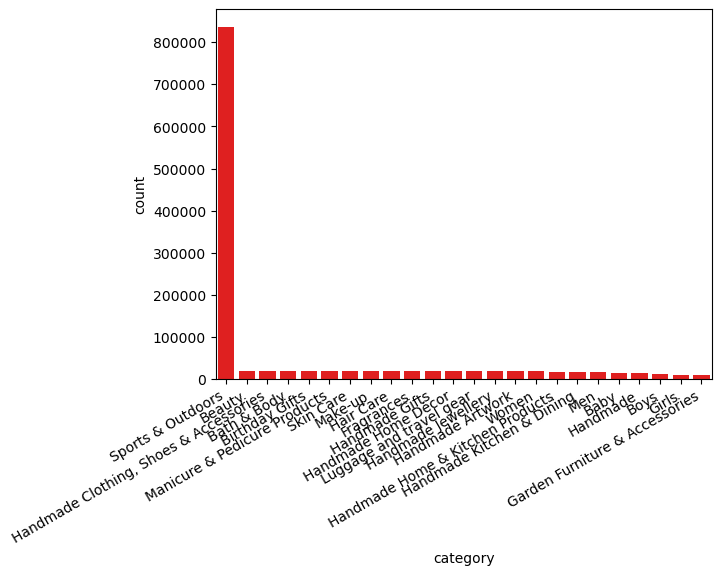

In [230]:
ax = sns.barplot(
    x="category",
    y='count',
    data=cat_viz,
    color='red',
    legend=True,
)
#to improve readability we can rotate the labels of x axes (the categories of the products)
ax = ax.set_xticks(ticks=ax.get_xticks(), labels=ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

we can exclude "Sports & Outdoors" to improve readability of the barplot

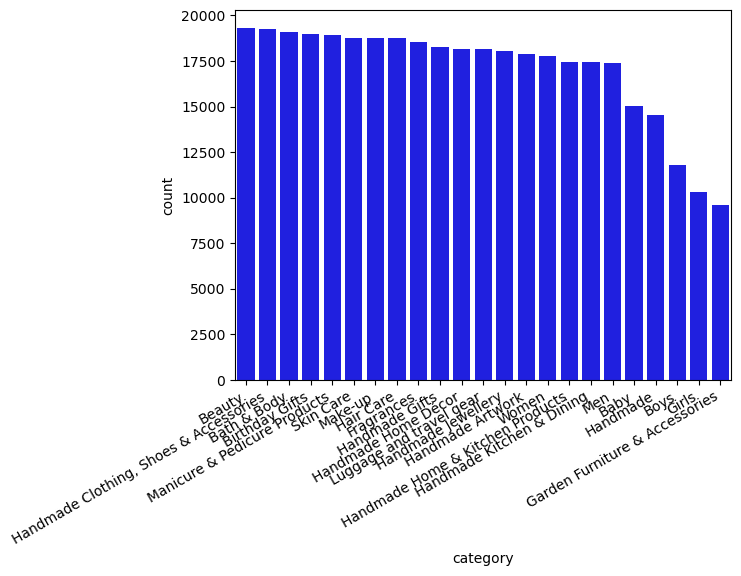

In [232]:

cat_viz2 = cat_viz[cat_viz["category"] != "Sports & Outdoors"]
ax = sns.barplot(
    x="category",
    y='count',
    data=cat_viz2,
    color='blue',
    legend=True,
)
#to improve readability we can rotate the labels of x axes (the categories of the products)
ax = ax.set_xticks(ticks=ax.get_xticks(), labels=ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

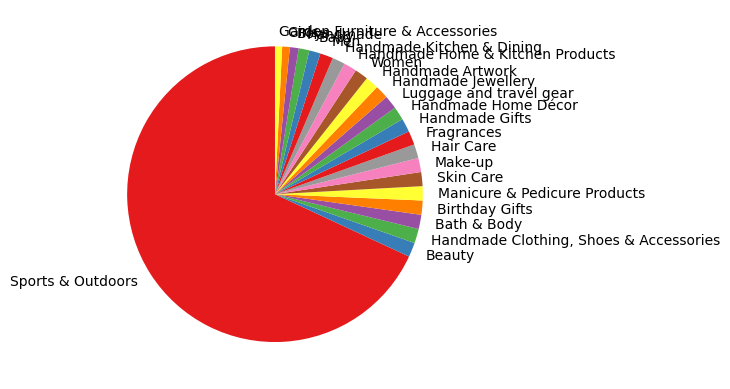

In [249]:
pie_cat = cat_viz.plot.pie(
    y = "perc_count" , 
    labels = cat_viz["category"], 
    startangle=90, 
    colors=sns.color_palette('Set1'))
pie_cat.get_legend().remove()
pie_cat.set_ylabel("")
plt.show(pie_cat)

The category "Sports & Outdoors" dominates the piechart

### Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**

In [275]:
key_stats = {
"mean" : round(num["price"].mean(),2),
"median" : num["price"].median(),
"mode" : num["price"].mode()[0]
}
print("Price statistics","\n","-"*len("Price statistics"))
for k,v in key_stats.items():
    print(f"{k} : {v}")

Price statistics 
 ----------------
mean : 89.24
median : 19.09
mode : 9.99


2. **Measures of Dispersion**

In [295]:
summary_num = round(num["price"].describe(),2)
summary_num["var"] = round(num["price"].var(),2)
summary_num["cv"] = round(summary_num["std"]/summary_num["mean"],2)
summary = pd.DataFrame(summary_num)
summary

,price
count,2443651.00
mean,89.24
std,345.61
min,0.00
25%,9.99
50%,19.09
75%,45.99
max,100000.00
var,119445.49
cv,3.87


**Insights**
- The average (mean) price of the products in the dataset is approximately `89.24 GPB`.
- The median price stands at `19.09 GPB`. Notably, the median is lower than the mean, suggesting a skew in the distribution of product prices towards higher values.
- The standard deviation, a measure of the amount of variation or dispersion in the product prices, is approximately `345.61 GPB`. This indicates that product prices can vary significantly (approx. `3.87 times`) from the average.
- The minimum and maximum prices are `0 GPB` and `100000 GPB`, respectively, highlighting a wide range of property values in the dataset.
- The interquartile range (IQR), given by the values at 25% (Q1) and 75% (Q3), is between `9.99 GPB` and `45.99 GPB`. This means that 50% of the products in the dataset are within this price range.

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

array([[<Axes: title={'center': 'price'}>]], dtype=object)

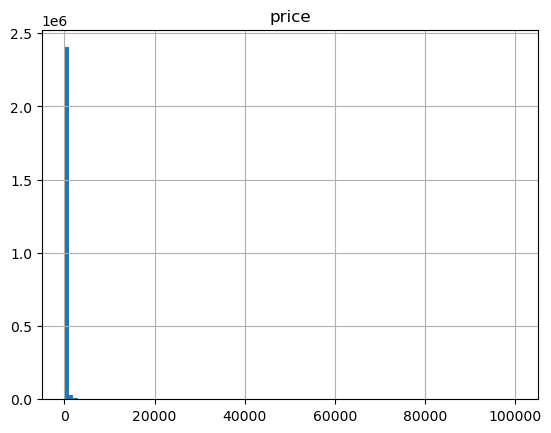

In [330]:
num.hist("price",bins = 100)

the histogram has been sliced into 100 intervals between 0 GPB and 100000 GPB, the reason why the histogram is hard to read is because there are too many products priced around value 0, but most importantly there are only few products that are priced more than 45.00 GPB (75%)

In [ ]:
q95 = num["price"].quantile(0.95)
q95
#num.loc[num["price"] == 100000] #if using ".loc"
##

np.float64(349.5)

In [338]:
num2 = num.loc[num["price"] <= q95]
num2

,stars,reviews,price,boughtInLastMonth
uid,,,,
1,4.7,15308,21.99,0
2,4.7,98099,23.99,0
3,4.7,15308,21.99,0
4,4.7,7205,31.99,0
5,4.6,1881,17.99,0
...,...,...,...,...
2828589,0.0,0,22.34,0
2828590,0.0,0,97.99,0
2828591,0.0,0,52.99,0


array([[<Axes: title={'center': 'price'}>]], dtype=object)

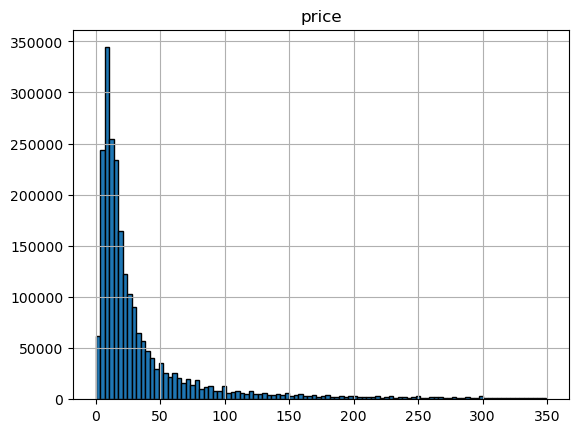

In [346]:
num2.hist("price",bins = 100, edgecolor='black')